# Load Important Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from neuralprophet import NeuralProphet
import joblib

# Load The Date_set

In [2]:
df = pd.read_csv('/Users/ahsanali/Desktop/AI Data/Internation_Projects_intern/Crime Hotspot Detection/LA_Crime_Data_from_2020_to_2024.csv')
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,03/01/2020 00:00,03/01/2020 00:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,02/09/2020 00:00,02/08/2020 00:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 00:00,11/04/2020 00:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,05/10/2023 00:00,03/10/2020 00:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,220614831,08/18/2022 12:00:00 AM,08/17/2020 12:00:00 AM,1200,6,Hollywood,666,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,1900 TRANSIENT,NaN,34.0944,-118.3277


# Select The Necessary Columns

In [3]:
df = df[['DR_NO','Date Rptd','DATE OCC','TIME OCC','Crm Cd Desc','LOCATION', 'Status Desc','Vict Age']]
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,Crm Cd Desc,LOCATION,Status Desc,Vict Age
0,190326475,03/01/2020 00:00,03/01/2020 00:00,2130,VEHICLE - STOLEN,1900 S LONGWOOD AV,Adult Arrest,0
1,200106753,02/09/2020 00:00,02/08/2020 00:00,1800,BURGLARY FROM VEHICLE,1000 S FLOWER ST,Invest Cont,47
2,200320258,11/11/2020 00:00,11/04/2020 00:00,1700,BIKE - STOLEN,1400 W 37TH ST,Invest Cont,19
3,200907217,05/10/2023 00:00,03/10/2020 00:00,2037,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),14000 RIVERSIDE DR,Invest Cont,19
4,220614831,08/18/2022 12:00:00 AM,08/17/2020 12:00:00 AM,1200,THEFT OF IDENTITY,1900 TRANSIENT,Invest Cont,28


# Convert TO DateTime 

In [4]:
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], errors='coerce')
df['TIME OCC'] = pd.to_datetime(df['TIME OCC'], format='%m/%d/%Y %H%M', errors='coerce').dt.time

In [5]:
df.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'Crm Cd Desc', 'LOCATION',
       'Status Desc', 'Vict Age'],
      dtype='object')

In [6]:
df = df[df['Crm Cd Desc'] == 'ROBBERY']
print(df['Status Desc'].value_counts().head(10))


Status Desc
Invest Cont     22302
Adult Arrest     5332
Adult Other      2547
Juv Arrest        580
Juv Other          54
Name: count, dtype: int64


# Visualization 

## 1.Analyze Robbery Trends Over Time: Group by date and count robberies

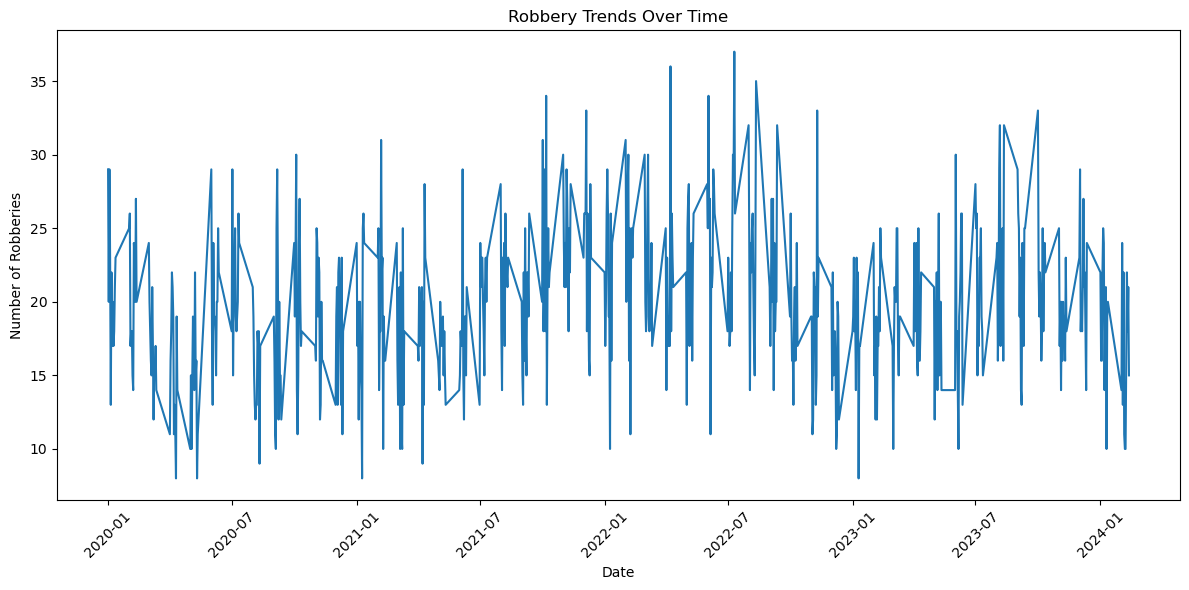

In [7]:
robberies_by_date = df.groupby('DATE OCC')['DR_NO'].count()
plt.figure(figsize=(12, 6))
plt.plot(robberies_by_date.index, robberies_by_date.values)
plt.xlabel('Date')
plt.ylabel('Number of Robberies')
plt.title('Robbery Trends Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## 2. Victim Age Distribution:

WARNING - (py.warnings._showwarnmsg) - /opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):



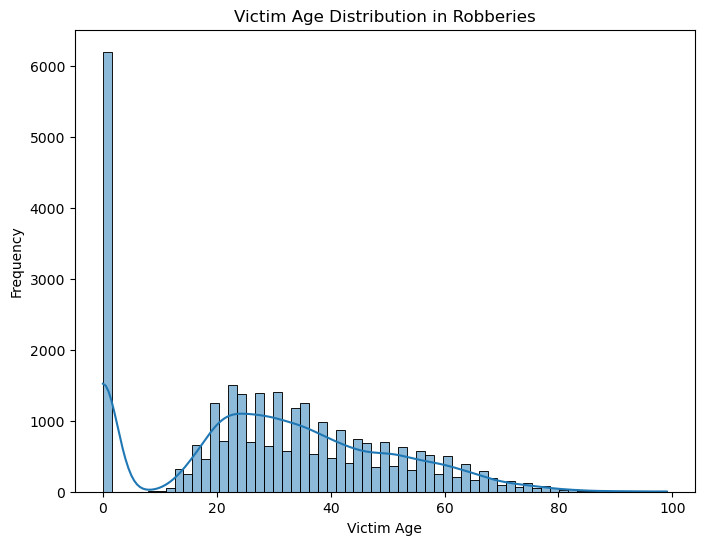

In [8]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Vict Age'], kde=True)
plt.xlabel('Victim Age')
plt.ylabel('Frequency')
plt.title('Victim Age Distribution in Robberies')
plt.show()

In [9]:
df.index = pd.DatetimeIndex(df['Date Rptd'])

In [10]:
df

,DR_NO,Date Rptd,DATE OCC,TIME OCC,Crm Cd Desc,LOCATION,Status Desc,Vict Age
Date Rptd,,,,,,,,
2022-03-21,220207597,03/21/2022 12:00:00 AM,2020-10-01,NaT,ROBBERY,1300 S ALVARADO ST,Invest Cont,62
2023-02-01,231305562,02/01/2023 00:00,2020-04-01,NaT,ROBBERY,12TH ST,Invest Cont,50
2020-12-09,211804895,12/09/2020 00:00,2020-12-09,NaT,ROBBERY,400 E 95TH ST,Invest Cont,53
2023-02-13,231905889,02/13/2023 12:00:00 AM,NaT,NaT,ROBBERY,14700 GLEDHILL ST,Invest Cont,18
2021-01-05,211904165,01/05/2021 00:00,NaT,NaT,ROBBERY,ROSCOE BL,Invest Cont,51
...,...,...,...,...,...,...,...,...
2023-05-20,230311153,05/20/2023 12:00:00 AM,NaT,NaT,ROBBERY,WESTERN AV,Invest Cont,17
2023-02-16,230505717,02/16/2023 12:00:00 AM,2023-02-12,NaT,ROBBERY,100 S GAFFEY ST,Invest Cont,78
2023-04-18,232008464,04/18/2023 12:00:00 AM,NaT,NaT,ROBBERY,200 S WESTMORELAND AV,Invest Cont,22


## Count the Yearly Crime 

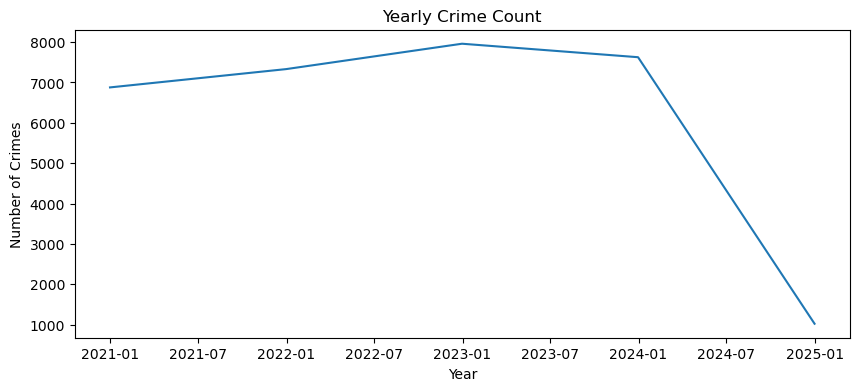

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(df.resample('Y').size())
plt.title('Yearly Crime Count')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.show()


## Count the Monthly Crime

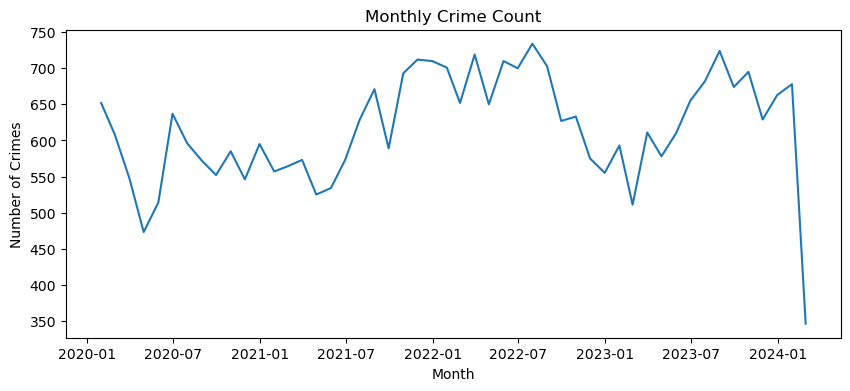

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(df.resample('M').size())
plt.title('Monthly Crime Count')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.show()


In [13]:
df_prophet = pd.DataFrame(df.resample('M').size().reset_index())
df_prophet.columns = ['ds','y']
df_prophet

,ds,y
0,2020-01-31,652
1,2020-02-29,608
2,2020-03-31,547
3,2020-04-30,473
4,2020-05-31,514
5,2020-06-30,637
6,2020-07-31,596
7,2020-08-31,572
8,2020-09-30,552
9,2020-10-31,585


# Model

In [14]:
model = NeuralProphet()
matrics = model.fit(df_prophet)

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency M corresponds to [98.]% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as M
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling weekly seasonality. Run NeuralProphet with weekly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 8
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 330


Training: |                                                                  | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (7) is too small than the required number                     for the learning rate finder (204). The results might not be optimal.


Finding best initial lr:   0%|          | 0/204 [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - /opt/anaconda3/lib/python3.11/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 8. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.

WARNING - (py.warnings._showwarnmsg) - /opt/anaconda3/lib/python3.11/site-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 2. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.



Training: |                                                                  | 0/? [00:00<?, ?it/s]

## Create future dataframe using your training DataFrame

In [15]:
future = model.make_future_dataframe(df_prophet, periods=24)
forecast = model.predict(future)

INFO - (NP.df_utils._infer_frequency) - Major frequency M corresponds to [98.]% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - M
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency M corresponds to [95.833]% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - M
INFO - (NP.df_utils._infer_frequency) - Major frequency M corresponds to [95.833]% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - M


Predicting: |                                                                | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


## Visualization Actual vs Predicted Crimes

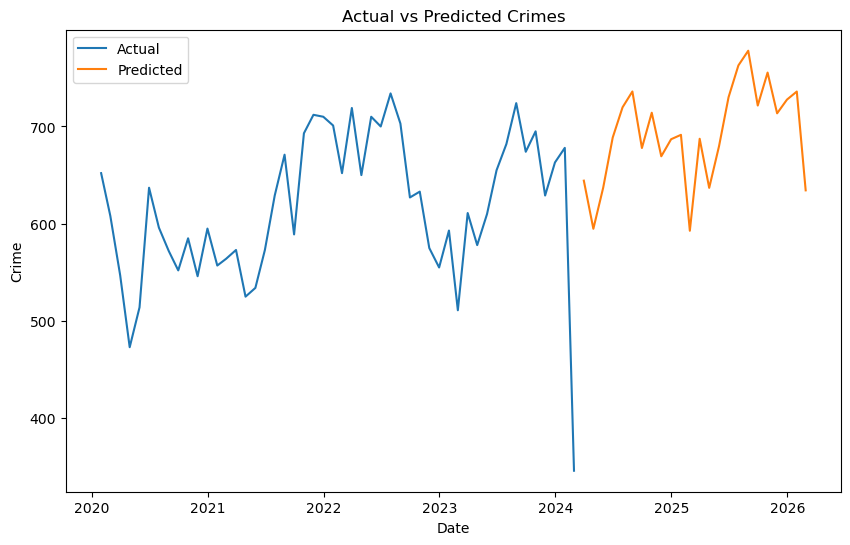

In [16]:
# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(df_prophet['ds'], df_prophet['y'], label='Actual')
plt.plot(forecast['ds'], forecast['yhat1'], label='Predicted')
plt.xlabel('Date')
plt.ylabel('Crime')
plt.title('Actual vs Predicted Crimes')
plt.legend()
plt.show()


# Save the Model

In [17]:
joblib.dump(model, 'Crime_Hotspot_Detection.pkl')

['Crime_Hotspot_Detection.pkl']